# Brain Tumor MRI Dataset - Exploratory Data Analysis

## 1. Project Overview

This notebook explores the Brain Tumor MRI dataset before model development.

The analysis includes:

- Dataset overview
- Class distribution
- Sample visualization
- Image resolution analysis
- Image format analysis
- Corrupted image detection

The goal is to understand the dataset characteristics before preprocessing and model training.

## 2. Import Libraries

In [1]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

%matplotlib inline
plt.style.use("ggplot")

## 3. Dataset Configuration

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

In [3]:
print(TRAIN_DIR)
print(TEST_DIR)

../data/raw/Training
../data/raw/Testing


## 4. Dataset Overview

In [4]:
classes = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
print(PROJECT_ROOT.resolve())
print(DATA_DIR.resolve())
print(TRAIN_DIR.resolve())
print(TEST_DIR.resolve())

/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai
/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw
/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw/Training
/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw/Testing


## 5. Class Distribution

In this section, we analyze the number of MRI images in each class for both the training and testing datasets.

Understanding class distribution is important because an imbalanced dataset can lead to biased model predictions.

### 5.1 Image Counting Function

In [6]:
def count_images(directory):
    """
    Count the number of images in each class folder.

    Parameters
    ----------
    directory : Path
        Path to Training or Testing folder.

    Returns
    -------
    dict
        Dictionary containing image counts for each class.
    """

    counts = {}

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            counts[class_dir.name] = len(list(class_dir.glob("*")))

    return counts

In [7]:
train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print(train_counts)
print(test_counts)

{'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
{'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


### 5.2 Dataset Distribution

In [8]:
distribution_df = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
})

distribution_df

,Training,Testing
glioma,1400,400
meningioma,1400,400
notumor,1400,400
pituitary,1400,400


### 5.3 Total Dataset

In [9]:
distribution_df["Total"] = (
    distribution_df["Training"] +
    distribution_df["Testing"]
)

distribution_df

,Training,Testing,Total
glioma,1400,400,1800
meningioma,1400,400,1800
notumor,1400,400,1800
pituitary,1400,400,1800


In [10]:
print(f"Total Training Images : {distribution_df['Training'].sum():,}")
print(f"Total Testing Images  : {distribution_df['Testing'].sum():,}")
print(f"Total Images          : {distribution_df['Total'].sum():,}")

Total Training Images : 5,600
Total Testing Images  : 1,600
Total Images          : 7,200


### 5.4 Visualization

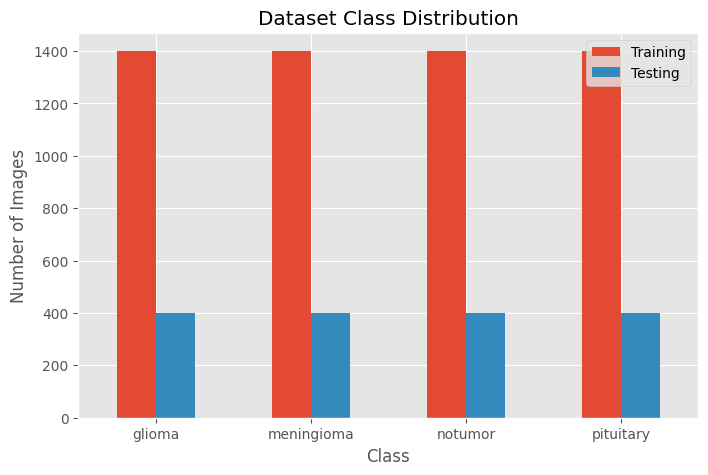

In [11]:
fig, ax = plt.subplots(figsize=(8,5))

distribution_df[["Training","Testing"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Dataset Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")

plt.xticks(rotation=0)

plt.show()

### 5.5 Observation

The dataset is perfectly balanced.
Each class contains:

- 1,400 training images
- 400 testing images

Balanced class distributions help reduce prediction bias during model training and provide more reliable evaluation results.

## 6. Image Format Analysis

In this section, we analyze the image file formats used in the dataset.

Understanding the image formats is important to ensure that the images can be processed consistently during preprocessing and model training.

### 6.1 Image Format Function

In [12]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".gif"}

def get_image_formats(directory):
    """
    Count image file formats in a directory.

    Parameters
    ----------
    directory : Path
        Path to the dataset directory.

    Returns
    -------
    Counter
        Count of files for each image format.
    """

    formats = Counter()

    for file in directory.rglob("*"):
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
            formats[file.suffix.lower()] += 1

    return formats

### 6.2 Format DIstribution

In [13]:
train_formats = get_image_formats(TRAIN_DIR)

print("Training image formats:")
print(train_formats)

Training image formats:
Counter({'.jpg': 5600})


In [14]:
test_formats = get_image_formats(TEST_DIR)

print("Testing image formats:")
print(test_formats)

Testing image formats:
Counter({'.jpg': 1600})


In [15]:
all_formats = get_image_formats(DATA_DIR)

print("All image formats:")
print(all_formats)

All image formats:
Counter({'.jpg': 7200})


### 6.3 Observation

All images in the dataset are stored in JPEG (`.jpg`) format. The training set contains 5,600 JPEG images, while the testing set contains 1,600 JPEG images, resulting in a total of 7,200 images.

The consistent image format simplifies the preprocessing pipeline because no additional format conversion is required before model training.


## 7. Image Resolution Analysis

In this section, we analyze the resolution of the MRI images in the dataset.

Understanding the original image resolution is important because deep learning models require images with a consistent input size. The analysis will help determine the appropriate preprocessing strategy before training the EfficientNetB0 model.

In [16]:
def get_image_resolutions(directory):
    """
    Get image resolutions from a dataset directory.

    Parameters
    ----------
    directory : Path
        Path to the dataset directory.

    Returns
    -------
    list
        List containing image resolutions as (width, height).
    """

    resolutions = []

    for file in directory.rglob("*"):

        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:

            try:
                with Image.open(file) as img:
                    resolutions.append(img.size)

            except Exception:
                pass

    return resolutions

### 7.1 Resolution Extraction

In [17]:
train_resolutions = get_image_resolutions(TRAIN_DIR)
test_resolutions = get_image_resolutions(TEST_DIR)

print(f"Training images analyzed : {len(train_resolutions):,}")
print(f"Testing images analyzed  : {len(test_resolutions):,}")

Training images analyzed : 5,600
Testing images analyzed  : 1,600


In [18]:
all_resolutions = train_resolutions + test_resolutions

print(f"Total images analyzed : {len(all_resolutions):,}")

Total images analyzed : 7,200


### 7.2 Unique Resolution

In [19]:
unique_resolutions = set(all_resolutions)

print(f"Unique resolutions : {len(unique_resolutions)}")

Unique resolutions : 447


In [20]:
for resolution in sorted(unique_resolutions):
    print(resolution)

(150, 198)
(173, 201)
(174, 230)
(175, 167)
(177, 197)
(180, 218)
(192, 192)
(194, 259)
(196, 257)
(197, 229)
(200, 200)
(200, 210)
(200, 223)
(200, 234)
(200, 235)
(200, 236)
(200, 243)
(200, 248)
(200, 249)
(200, 252)
(201, 207)
(201, 210)
(201, 244)
(201, 249)
(201, 250)
(201, 251)
(202, 202)
(202, 223)
(202, 250)
(203, 243)
(203, 248)
(204, 245)
(204, 247)
(204, 249)
(205, 214)
(205, 249)
(205, 251)
(206, 244)
(206, 245)
(206, 249)
(207, 207)
(207, 225)
(207, 243)
(208, 217)
(208, 225)
(208, 242)
(208, 243)
(208, 248)
(208, 278)
(209, 225)
(209, 234)
(209, 241)
(209, 242)
(210, 201)
(210, 213)
(210, 234)
(210, 240)
(210, 264)
(211, 236)
(211, 239)
(212, 222)
(212, 236)
(212, 237)
(212, 238)
(212, 280)
(213, 236)
(213, 237)
(214, 216)
(214, 235)
(214, 236)
(215, 220)
(215, 234)
(216, 202)
(216, 216)
(216, 234)
(216, 293)
(216, 302)
(217, 232)
(217, 248)
(218, 231)
(218, 234)
(219, 211)
(219, 234)
(220, 212)
(220, 275)
(221, 228)
(221, 257)
(222, 252)
(224, 216)
(224, 219)
(224, 223)

### 7.3 Resolution Frequency

In [21]:
resolution_counts = Counter(all_resolutions)

resolution_df = pd.DataFrame(
    resolution_counts.items(),
    columns=["Resolution", "Count"]
)

resolution_df = resolution_df.sort_values(
    by="Count",
    ascending=False
)

resolution_df.head(20)

,Resolution,Count
0,"(512, 512)",5014
1,"(225, 225)",338
33,"(630, 630)",90
27,"(201, 251)",57
79,"(228, 221)",51
30,"(232, 217)",50
62,"(236, 236)",48
9,"(442, 442)",48
43,"(150, 198)",44
35,"(200, 252)",43


In [22]:
non_512_count = len(all_resolutions) - resolution_counts[(512, 512)]

print(f"512 × 512 images     : {resolution_counts[(512, 512)]:,}")
print(f"Non-512 × 512 images : {non_512_count:,}")

512 × 512 images     : 5,014
Non-512 × 512 images : 2,186


In [23]:
non_512_percentage = (
    non_512_count / len(all_resolutions) * 100
)

print(f"Non-512 × 512 percentage : {non_512_percentage:.2f}%")

Non-512 × 512 percentage : 30.36%


### 7.4 Most Common Image Resolutions

The following visualization shows the 20 most common image resolutions in the dataset. Since the dataset contains 447 unique resolutions, displaying all resolutions in a single chart would make the visualization difficult to interpret.


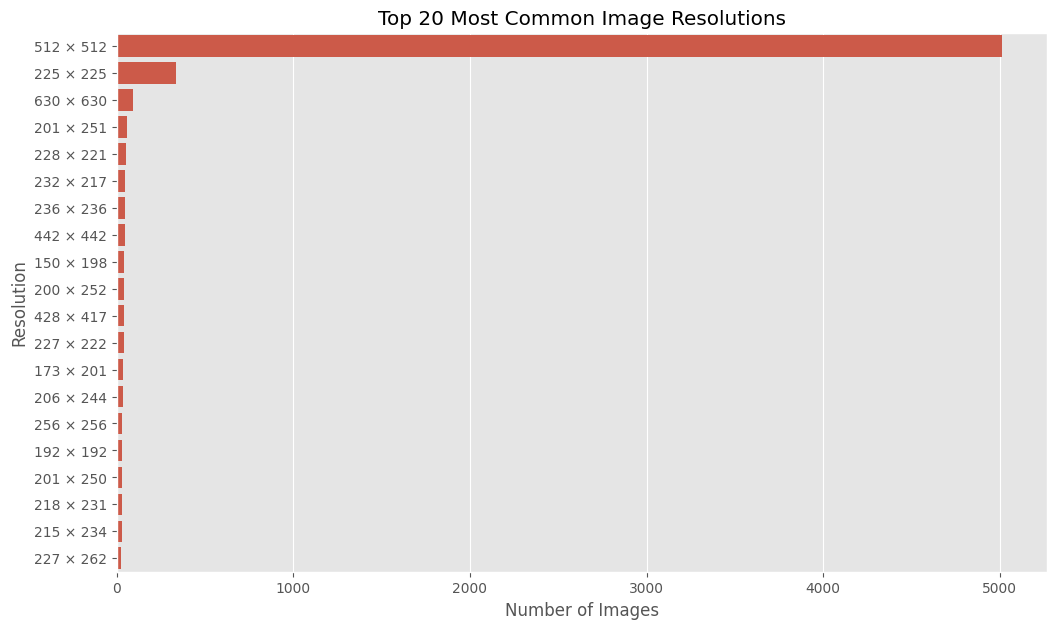

In [24]:
top_resolutions = resolution_df.head(20).copy()

top_resolutions["Resolution"] = top_resolutions["Resolution"].apply(
    lambda x: f"{x[0]} × {x[1]}"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_resolutions,
    x="Count",
    y="Resolution"
)

plt.title("Top 20 Most Common Image Resolutions")
plt.xlabel("Number of Images")
plt.ylabel("Resolution")

plt.show()

In [25]:
resolution_group_df = pd.DataFrame({
    "Category": [
        "512 × 512",
        "Other Resolutions"
    ],
    "Count": [
        resolution_counts[(512, 512)],
        non_512_count
    ]
})

resolution_group_df

,Category,Count
0,512 × 512,5014
1,Other Resolutions,2186


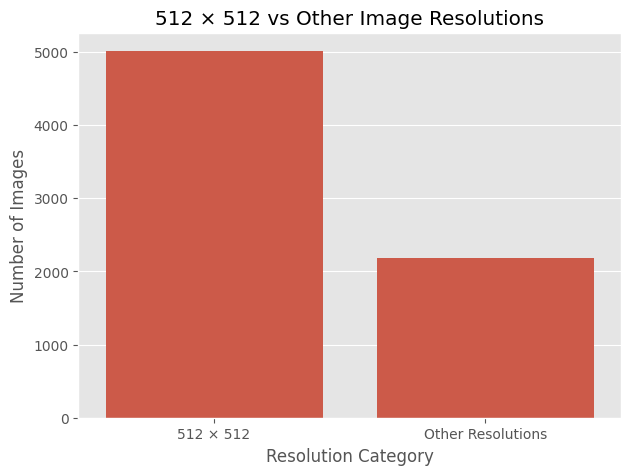

In [26]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=resolution_group_df,
    x="Category",
    y="Count"
)

plt.title("512 × 512 vs Other Image Resolutions")
plt.xlabel("Resolution Category")
plt.ylabel("Number of Images")

plt.show()

### 7.5 Observation

The dataset contains 7,200 MRI images with 447 unique image resolutions. The most common resolution is 512 × 512, accounting for 5,014 images (69.64%) of the dataset. The remaining 2,186 images (30.36%) have different resolutions.

The substantial variation in image dimensions indicates that image resizing will be required during preprocessing to ensure a consistent input size for the EfficientNetB0 model.


## 8. Sample Visualization

In this section, sample MRI images from each class are visualized to observe their visual characteristics and variations.

Four sample images are selected from each class, resulting in 16 images in total. This visualization provides an initial understanding of the dataset before image preprocessing and model training.

### Make  a Visualization

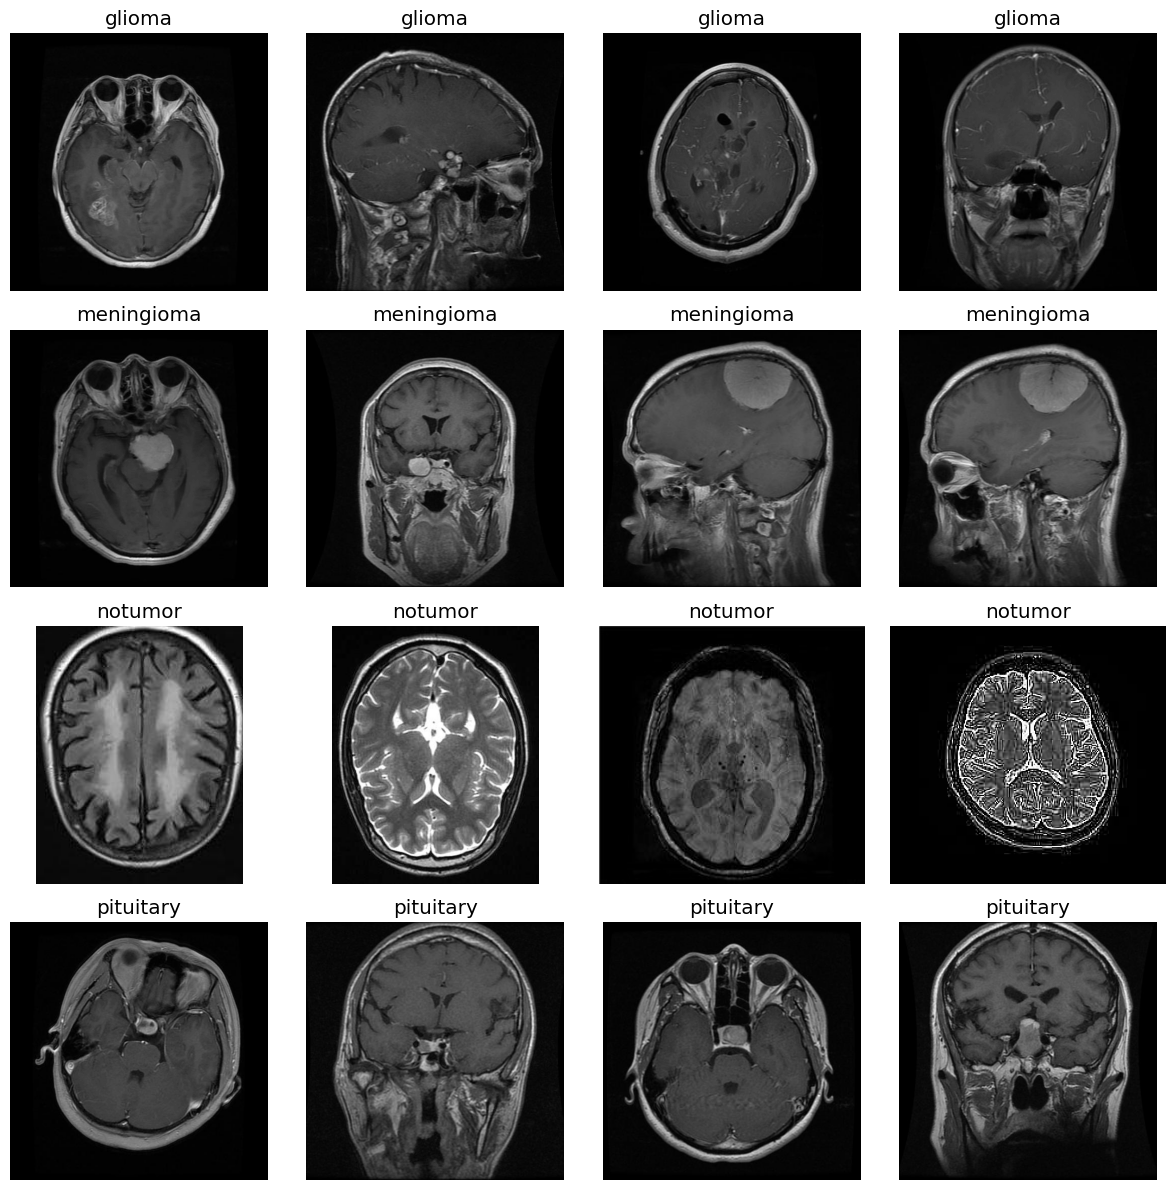

In [27]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

for row, class_name in enumerate(classes):

    class_dir = TRAIN_DIR / class_name

    image_files = [
        file
        for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    selected_images = image_files[:4]

    for col, image_path in enumerate(selected_images):

        with Image.open(image_path) as img:
            axes[row, col].imshow(img, cmap="gray")

        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### Observation

The sample visualization reveals substantial variation in the visual characteristics of the MRI images across the four classes.

First, the images have varying original aspect ratios and dimensions. Although the samples are displayed within a square visualization frame, their original aspect ratios are not necessarily square. This variation is consistent with the resolution analysis, which identified 447 unique image resolutions.

Second, the dataset contains different anatomical viewing planes, including axial, sagittal, and coronal views. The orientation of the MRI images is therefore not consistent across the dataset.

The images also show variation in background margins, brightness, contrast, and visual quality. Most images contain a black background, but the thickness of the surrounding margins varies between samples. Differences in brightness and contrast are also observed, which may be related to variations in MRI acquisition characteristics and image sources.

Furthermore, the dataset contains differences in image sharpness, noise, cropping, and brain positioning. Some images use a relatively tight crop around the brain, while others include a larger portion of the head and neck region. The position of the brain within the image also varies between samples.

Overall, the sample visualization indicates that the dataset contains considerable visual variability. These characteristics should be considered during the preprocessing and model development stages to improve the robustness of the classification model.


## 9. Corrupted Image Detection

In this section, we check the integrity of the MRI images to identify files that cannot be opened or decoded correctly.

Detecting corrupted images is important before preprocessing and model training because unreadable or damaged files may cause errors during the data loading and training process.


In [28]:
def find_corrupted_images(directory):
    """
    Detect corrupted or unreadable image files.

    Parameters
    ----------
    directory : Path
        Path to the dataset directory.

    Returns
    -------
    list
        List of corrupted image paths.
    """

    corrupted = []

    for file in directory.rglob("*"):

        if not file.is_file():
            continue

        if file.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            with Image.open(file) as img:
                img.verify()

        except Exception:
            corrupted.append(file)

    return corrupted

In [29]:
corrupted_images = find_corrupted_images(DATA_DIR)

print(f"Corrupted images: {len(corrupted_images)}")

Corrupted images: 0


In [30]:
for image_path in corrupted_images:
    print(image_path)

In [31]:
print(f"Total images checked: {len(train_resolutions) + len(test_resolutions):,}")

Total images checked: 7,200


### Observation

The integrity check was performed on all 7,200 MRI images in the dataset. The result shows that no corrupted or unreadable image files were detected.

A total of 5,600 training images and 1,600 testing images were successfully checked. This indicates that all images can be read successfully and are suitable for the next stages of the data processing pipeline.

## 10. EDA Summary

The exploratory data analysis provides several important findings about the Brain Tumor MRI dataset.

* The dataset contains 7,200 valid MRI images, consisting of 5,600 training images and 1,600 testing images.
* The four classes are perfectly balanced, with 1,400 training images and 400 testing images per class.
* All images are stored in JPEG (`.jpg`) format.
* The dataset contains 447 unique image resolutions, with 5,014 images (69.64%) using a resolution of 512 × 512.
* Approximately 30.36% of the images have resolutions other than 512 × 512.
* The sample visualization reveals substantial variation in anatomical viewing planes, aspect ratios, cropping, brightness, contrast, image quality, and brain positioning.
* No corrupted or unreadable images were detected among the 7,200 images analyzed.

These findings indicate that the dataset is suitable for further development, but image preprocessing is required to standardize the input dimensions and account for the visual variability observed in the dataset.
